# Outfit Finder — Full-Sleeve Shirts ML Pipeline

**Pipeline:** TF-IDF → TruncatedSVD (Latent Semantic Analysis) → KMeans Clustering → Hybrid Cosine + Cluster Scoring

30 shirts: 17 permanent DummyJSON/Pexels images + 13 uploaded to catbox.moe (permanent CDN).

Run all cells top-to-bottom. No external backend or API required.

## Cell 1 — Imports & Dependency Check

In [ ]:
import sys, subprocess

# Map install-name → importable module name (scikit-learn installs as sklearn)
_PKGS = {'scikit-learn': 'sklearn', 'pandas': 'pandas', 'numpy': 'numpy',
         'requests': 'requests', 'matplotlib': 'matplotlib'}
for _pkg, _mod in _PKGS.items():
    try:
        __import__(_mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

import os, pickle, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
print('All dependencies ready.')


All dependencies ready.


## Cell 2 — Dataset: 30 Full-Sleeve Shirts

All image URLs are **permanent** working links:
- **DummyJSON CDN** — 3D product renders, full sleeves on white background
- **Pexels CDN** — on-person photography, confirmed full-sleeve
- **catbox.moe CDN** — 13 shirts uploaded permanently from user-provided Kaggle images

In [ ]:
# --- Permanent CDN image pools (DummyJSON product renders + Pexels) ---
DJ_BLUE  = 'https://cdn.dummyjson.com/product-images/mens-shirts/blue-&-black-check-shirt'
DJ_PLAID = 'https://cdn.dummyjson.com/product-images/mens-shirts/man-plaid-shirt'
DJ_CHECK = 'https://cdn.dummyjson.com/product-images/mens-shirts/men-check-shirt'
PX_DRESS = 'https://images.pexels.com/photos/1043471/pexels-photo-1043471.jpeg?auto=compress&cs=tinysrgb&w=400'
PX_PLAID = 'https://images.pexels.com/photos/769733/pexels-photo-769733.jpeg?auto=compress&cs=tinysrgb&w=400'

# --- catbox.moe CDN (permanent, uploaded from Kaggle dataset) ---
KG_102  = 'https://files.catbox.moe/ceg6oi.jpg'
KG_107  = 'https://files.catbox.moe/reawti.jpg'
KG_1022 = 'https://files.catbox.moe/pjyh2a.jpg'
KG_1033 = 'https://files.catbox.moe/74vybp.jpg'
KG_1034 = 'https://files.catbox.moe/la2d17.jpg'
KG_1044 = 'https://files.catbox.moe/xwlpud.jpg'
KG_1049 = 'https://files.catbox.moe/p0mmts.jpg'
KG_1061 = 'https://files.catbox.moe/q8c4km.jpg'
KG_1062 = 'https://files.catbox.moe/rw90nd.jpg'
KG_1063 = 'https://files.catbox.moe/mmqevr.jpg'
KG_1072 = 'https://files.catbox.moe/3jy852.jpg'
KG_1077 = 'https://files.catbox.moe/3cavsk.jpg'
KG_1100 = 'https://files.catbox.moe/4jxzhv.jpg'

RAW_SHIRTS = [
    # ── FORMAL (DummyJSON button-down product renders) ────────────────────
    {
        'id': 1, 'name': 'Classic White Oxford',
        'style': 'formal', 'color': 'white', 'pattern': 'plain', 'fabric': 'cotton', 'fit': 'slim',
        'occasion': 'office wedding interview business',
        'description': 'Crisp white oxford shirt with button-down collar. Slim fit for formal occasions, office wear, and weddings. Pure cotton, breathable and wrinkle-resistant.',
        'image_url': f'{DJ_BLUE}/1.webp'
    },
    {
        'id': 2, 'name': 'Navy Blue Pinstripe',
        'style': 'formal', 'color': 'navy blue', 'pattern': 'striped', 'fabric': 'wool blend', 'fit': 'regular',
        'occasion': 'office business meeting corporate boardroom',
        'description': 'Navy blue shirt with fine white pinstripes. Professional for business meetings and corporate environments. Wool blend for a sharp, structured silhouette.',
        'image_url': f'{DJ_BLUE}/2.webp'
    },
    {
        'id': 3, 'name': 'Teal Poplin Dress Shirt',
        'style': 'formal', 'color': 'teal', 'pattern': 'plain', 'fabric': 'poplin cotton', 'fit': 'slim',
        'occasion': 'office cocktail party smart formal wedding event',
        'description': 'Elegant teal poplin dress shirt with smooth, lustrous finish and French placket. Versatile from office use to cocktail parties and weddings.',
        'image_url': f'{DJ_CHECK}/1.webp'
    },
    {
        'id': 4, 'name': 'Slim Black Formal Dress Shirt',
        'style': 'formal', 'color': 'black', 'pattern': 'plain', 'fabric': 'cotton satin', 'fit': 'slim',
        'occasion': 'black tie gala evening formal tuxedo dinner',
        'description': 'Sleek all-black formal dress shirt in cotton-satin. Hidden placket and spread collar. Pairs with tuxedo or dark suit for black-tie events and galas.',
        'image_url': f'{DJ_PLAID}/4.webp'
    },
    {
        'id': 5, 'name': 'Burgundy Velvet Evening Shirt',
        'style': 'formal', 'color': 'burgundy', 'pattern': 'plain', 'fabric': 'velvet', 'fit': 'slim',
        'occasion': 'gala evening dinner party formal upscale event',
        'description': 'Luxurious burgundy velvet shirt with mandarin collar. A statement piece for galas, dinner parties, and black-tie-optional events.',
        'image_url': f'{DJ_PLAID}/1.webp'
    },
    {
        'id': 6, 'name': 'Grey Herringbone Oxford',
        'style': 'formal', 'color': 'grey', 'pattern': 'herringbone', 'fabric': 'cotton', 'fit': 'regular',
        'occasion': 'business casual office autumn winter corporate',
        'description': 'Subtle grey herringbone weave oxford. Textured pattern adds visual depth. Reliable business-casual choice for colder months and office settings.',
        'image_url': f'{DJ_BLUE}/3.webp'
    },
    # ── SMART CASUAL ──────────────────────────────────────────────────────────
    {
        'id': 7, 'name': 'Pastel Pink Oxford',
        'style': 'smart casual', 'color': 'pastel pink', 'pattern': 'plain', 'fabric': 'cotton', 'fit': 'slim',
        'occasion': 'brunch office smart casual date spring summer',
        'description': 'Soft pastel pink oxford cotton shirt with modern slim fit. Fresh for spring brunches, smart casual dates, and light office environments.',
        'image_url': PX_DRESS
    },
    {
        'id': 8, 'name': 'Blue Henley Long Sleeve',
        'style': 'smart casual', 'color': 'blue', 'pattern': 'plain henley', 'fabric': 'cotton', 'fit': 'slim',
        'occasion': 'casual date brunch outdoor smart casual weekend',
        'description': 'Clean blue henley long sleeve with a classic three-button placket. Slim cotton build that transitions from weekend brunches to smart casual dates effortlessly.',
        'image_url': KG_1062
    },
    {
        'id': 9, 'name': 'Teal Mint Henley Long Sleeve',
        'style': 'smart casual', 'color': 'teal mint', 'pattern': 'plain henley', 'fabric': 'cotton', 'fit': 'slim',
        'occasion': 'casual date brunch spring summer smart casual outdoor',
        'description': 'Fresh teal-mint henley long sleeve in lightweight cotton. The cool tone is ideal for spring and summer smart casual looks, dates, and outdoor outings.',
        'image_url': KG_1061
    },
    {
        'id': 10, 'name': 'Beige Ribbed Knit Long Sleeve',
        'style': 'smart casual', 'color': 'beige cream', 'pattern': 'ribbed textured', 'fabric': 'ribbed cotton', 'fit': 'slim',
        'occasion': 'casual smart casual date autumn weekend layering',
        'description': 'Warm beige ribbed-knit long sleeve with a slim, tailored silhouette. Subtle texture elevates casual dressing for dates, weekends, and autumn layering.',
        'image_url': KG_1033
    },
    {
        'id': 11, 'name': 'White Minimal Long Sleeve',
        'style': 'smart casual', 'color': 'white', 'pattern': 'plain', 'fabric': 'cotton jersey', 'fit': 'regular',
        'occasion': 'casual everyday smart casual minimal clean layering',
        'description': 'Crisp white long-sleeve cotton jersey with a clean minimal design. A versatile wardrobe essential for smart casual outfits, layering, and everyday wear.',
        'image_url': KG_1034
    },
    {
        'id': 12, 'name': 'Cream Pocket Long Sleeve',
        'style': 'smart casual', 'color': 'cream white', 'pattern': 'plain', 'fabric': 'cotton', 'fit': 'regular',
        'occasion': 'casual smart casual everyday minimal weekend date',
        'description': 'Understated cream long-sleeve with a chest pocket detail. Premium cotton build for a clean, effortless look on weekends and smart casual settings.',
        'image_url': KG_1072
    },
    {
        'id': 13, 'name': 'Pale Yellow Oxford Buttondown',
        'style': 'smart casual', 'color': 'pale yellow', 'pattern': 'plain', 'fabric': 'oxford cotton', 'fit': 'regular',
        'occasion': 'office spring brunch smart casual date',
        'description': 'Sunny pale yellow oxford button-down with soft basket-weave texture. A fresh alternative to white for office wear and spring smart-casual dressing.',
        'image_url': f'{DJ_CHECK}/3.webp'
    },
    {
        'id': 14, 'name': 'Dark Green Slim Poplin',
        'style': 'smart casual', 'color': 'dark green', 'pattern': 'plain', 'fabric': 'poplin', 'fit': 'slim',
        'occasion': 'office casual dinner date autumn winter',
        'description': 'Deep forest green slim-fit poplin. Rich green tone pairs with chinos, navy trousers, or dark denim for autumn office wear and evening dinners.',
        'image_url': f'{DJ_CHECK}/4.webp'
    },
    # ── CASUAL ────────────────────────────────────────────────────────────────
    {
        'id': 15, 'name': 'Charcoal Flannel Check',
        'style': 'casual', 'color': 'charcoal grey', 'pattern': 'checked', 'fabric': 'flannel', 'fit': 'relaxed',
        'occasion': 'weekend outing casual brunch coffee',
        'description': 'Soft charcoal flannel shirt with classic window-pane check. Relaxed fit makes it ideal for weekend outings, brunches, and casual everyday wear.',
        'image_url': f'{DJ_BLUE}/2.webp'
    },
    {
        'id': 16, 'name': 'Red Tartan Flannel',
        'style': 'casual', 'color': 'red black', 'pattern': 'tartan plaid', 'fabric': 'flannel', 'fit': 'relaxed',
        'occasion': 'winter casual christmas holiday cozy warm outdoor',
        'description': 'Bold red and black tartan flannel shirt for colder months. Warm, eye-catching plaid ideal for Christmas holidays, cozy winter gatherings, and casual cold-weather dressing.',
        'image_url': f'{DJ_PLAID}/1.webp'
    },
    {
        'id': 17, 'name': 'Brown Buffalo Check',
        'style': 'casual', 'color': 'brown black', 'pattern': 'buffalo check', 'fabric': 'cotton flannel', 'fit': 'regular',
        'occasion': 'casual everyday autumn winter outdoor lumberjack',
        'description': 'Earthy brown and black buffalo check flannel. Timeless pattern with warm cotton flannel. Pairs with jeans or chinos for casual autumn and winter wear.',
        'image_url': PX_PLAID
    },
    {
        'id': 18, 'name': 'Denim Chambray Work Shirt',
        'style': 'casual', 'color': 'denim blue', 'pattern': 'plain', 'fabric': 'chambray denim', 'fit': 'regular',
        'occasion': 'everyday casual work from home weekend',
        'description': 'Classic denim chambray shirt in washed blue. Lightweight and versatile for everyday casual wear, work from home, and laid-back weekends.',
        'image_url': f'{DJ_BLUE}/3.webp'
    },
    {
        'id': 19, 'name': 'Beige Oversized Long Sleeve',
        'style': 'casual', 'color': 'beige taupe', 'pattern': 'plain', 'fabric': 'cotton fleece', 'fit': 'oversized',
        'occasion': 'weekend casual cozy relaxed everyday loungewear layering',
        'description': 'Warm beige oversized long-sleeve top in soft cotton fleece. The relaxed boxy fit is made for cozy weekends, lounging, and effortless street casual dressing.',
        'image_url': KG_102
    },
    {
        'id': 20, 'name': 'Forest Green Flannel Plaid',
        'style': 'casual', 'color': 'forest green', 'pattern': 'plaid', 'fabric': 'flannel', 'fit': 'regular',
        'occasion': 'camping hiking outdoor autumn fall rugged',
        'description': 'Rugged forest green plaid flannel for the outdoors. Warm and durable for camping, hiking, and autumn activities. Classic lumberjack aesthetic.',
        'image_url': f'{DJ_PLAID}/2.webp'
    },
    {
        'id': 21, 'name': 'Brick Red Madras Plaid',
        'style': 'casual', 'color': 'brick red', 'pattern': 'madras plaid', 'fabric': 'cotton madras', 'fit': 'regular',
        'occasion': 'summer casual garden barbecue beach weekend',
        'description': 'Bright brick red madras plaid in lightweight cotton. Wear open over a tee or buttoned at barbecues, garden parties, and beach days.',
        'image_url': f'{DJ_PLAID}/3.webp'
    },
    # ── STREETWEAR (Kaggle verified long-sleeve tees) ─────────────────────────
    {
        'id': 22, 'name': 'Black Designer Long Sleeve',
        'style': 'streetwear', 'color': 'black', 'pattern': 'plain', 'fabric': 'cotton jersey', 'fit': 'slim',
        'occasion': 'street style party night out designer fashion luxury',
        'description': 'Premium black long-sleeve jersey from designer streetwear. Clean minimal branding on quality cotton. Effortlessly elevated for parties, concerts, and fashion-forward looks.',
        'image_url': KG_1022
    },
    {
        'id': 23, 'name': 'Black Branded Long Sleeve',
        'style': 'streetwear', 'color': 'black', 'pattern': 'plain', 'fabric': 'cotton jersey', 'fit': 'regular',
        'occasion': 'streetwear casual everyday night out concert event',
        'description': 'Versatile black branded long-sleeve in heavy cotton jersey. Bold graphic text across the chest. A streetwear staple for concerts, night outs, and everyday casual dressing.',
        'image_url': KG_1049
    },
    {
        'id': 24, 'name': 'White Graphic Trail Long Sleeve',
        'style': 'casual', 'color': 'white', 'pattern': 'printed graphic', 'fabric': 'cotton jersey', 'fit': 'regular',
        'occasion': 'outdoor casual travel adventure everyday graphic print',
        'description': 'White long-sleeve cotton jersey with an outdoor trail graphic. Clean base with nature-inspired branding for casual adventure, travel, and everyday wear.',
        'image_url': KG_1100
    },
    {
        'id': 25, 'name': 'Grey Melange Patch Long Sleeve',
        'style': 'casual', 'color': 'grey melange', 'pattern': 'plain', 'fabric': 'cotton blend', 'fit': 'regular',
        'occasion': 'casual everyday weekend sport active layering',
        'description': 'Heathered grey melange long-sleeve with a woven patch label. Soft cotton-blend fabric with a relaxed everyday fit. Works alone or as a base layer for sport and casual wear.',
        'image_url': KG_1044
    },
    {
        'id': 26, 'name': 'Grey Essentials Long Sleeve',
        'style': 'streetwear', 'color': 'grey', 'pattern': 'printed graphic', 'fabric': 'cotton fleece', 'fit': 'oversized',
        'occasion': 'streetwear casual relaxed everyday luxury designer loungewear',
        'description': 'Oversized grey cotton-fleece long-sleeve with tonal graphic print. Fear of God Essentials aesthetic — a luxe casual staple for relaxed streetwear dressing.',
        'image_url': KG_1077
    },
    # ── RESORT CASUAL ────────────────────────────────────────────────────────
    {
        'id': 27, 'name': 'Navy Linen Pocket Long Sleeve',
        'style': 'resort casual', 'color': 'navy blue', 'pattern': 'plain', 'fabric': 'linen', 'fit': 'relaxed',
        'occasion': 'summer beach resort vacation dinner smart casual nautical',
        'description': 'Relaxed navy linen long-sleeve with a chest patch pocket. Lightweight and breathable for beach resorts, summer dinners, and nautical-inspired smart casual outfits.',
        'image_url': KG_1063
    },
    {
        'id': 28, 'name': 'Burgundy Outdoor Long Sleeve',
        'style': 'resort casual', 'color': 'burgundy dark red', 'pattern': 'plain', 'fabric': 'polyester blend', 'fit': 'regular',
        'occasion': 'outdoor hiking sport active travel adventure casual',
        'description': 'Rich burgundy performance long-sleeve in moisture-wicking polyester blend. Worn with a relaxed fit — ideal for outdoor adventures, hiking, and active travel.',
        'image_url': KG_107
    },
    {
        'id': 29, 'name': 'Royal Blue Batik Print',
        'style': 'resort casual', 'color': 'royal blue', 'pattern': 'batik printed', 'fabric': 'cotton voile', 'fit': 'relaxed',
        'occasion': 'travel holiday cultural ethnic festival beach bohemian',
        'description': 'Royal blue cotton voile with artisan batik wax-resist print. Lightweight and culturally rich for cultural festivals, travel, beach holidays, and bohemian styling.',
        'image_url': f'{DJ_BLUE}/2.webp'
    },
    # ── ATHLEISURE ────────────────────────────────────────────────────────────
    {
        'id': 30, 'name': 'Slate Grey Performance Shirt',
        'style': 'athleisure', 'color': 'slate grey', 'pattern': 'plain', 'fabric': 'polyester spandex blend', 'fit': 'athletic',
        'occasion': 'gym sport running workout active travel fitness',
        'description': 'Slate grey performance shirt with moisture-wicking polyester-spandex. Four-way stretch for full range of motion at the gym, running, and active lifestyles.',
        'image_url': f'{DJ_BLUE}/3.webp'
    },
]

df_raw = pd.DataFrame(RAW_SHIRTS)
print(f'Dataset loaded: {len(df_raw)} full-sleeve shirts')
print(f'Styles covered: {sorted(df_raw["style"].unique())}')
df_raw[['id','name','style','color','pattern']].head(10)

Dataset loaded: 30 full-sleeve shirts
Styles covered: ['athleisure', 'casual', 'formal', 'resort casual', 'smart casual', 'streetwear']


,id,name,style,color,pattern
0,1,Classic White Oxford,formal,white,plain
1,2,Navy Blue Pinstripe,formal,navy blue,striped
2,3,Teal Poplin Dress Shirt,formal,teal,plain
3,4,Slim Black Formal Dress Shirt,formal,black,plain
4,5,Burgundy Velvet Evening Shirt,formal,burgundy,plain
5,6,Grey Herringbone Oxford,formal,grey,herringbone
6,7,Pastel Pink Oxford,smart casual,pastel pink,plain
7,8,Blue Henley Long Sleeve,smart casual,blue,plain henley
8,9,Teal Mint Henley Long Sleeve,smart casual,teal mint,plain henley
9,10,Beige Ribbed Knit Long Sleeve,smart casual,beige cream,ribbed textured


## Cell 3 — Image Validation (Broken Link Detection)

In [ ]:
def is_image_valid(url: str, timeout: int = 10) -> bool:
    """HEAD first (fast); falls back to streaming GET if HEAD is rejected (e.g. catbox.moe)."""
    try:
        resp = requests.head(url, timeout=timeout, allow_redirects=True)
        if resp.status_code == 200:
            ct = resp.headers.get('Content-Type', '')
            return ct.startswith('image/')
        # HEAD not supported or redirected weirdly — try GET with stream to avoid downloading body
        resp = requests.get(url, timeout=timeout, allow_redirects=True, stream=True)
        ct = resp.headers.get('Content-Type', '')
        resp.close()
        return resp.status_code == 200 and ct.startswith('image/')
    except Exception:
        return False

# Validate unique URLs only (avoids redundant checks for shared DummyJSON paths)
unique_urls = df_raw['image_url'].unique()
print(f'Checking {len(unique_urls)} unique image URLs...')

url_status = {}
broken = []
for url in unique_urls:
    valid = is_image_valid(url)
    url_status[url] = valid
    status = '✓' if valid else '✗ BROKEN'
    # Shorten URL for readable display
    parts = url.split('/')
    short = parts[-2] + '/' + parts[-1].split('?')[0]
    print(f'  [{status}] ...{short}')
    if not valid:
        broken.append(url)

if not broken:
    print(f'''
All {len(unique_urls)} image URLs are valid. Dataset is clean.''')
else:
    print(f'''
{len(broken)} broken URL(s):''')
    for b in broken:
        print(f'  {b}')

df_clean = df_raw.copy()


Checking 25 unique image URLs...
  [✓] ...blue-&-black-check-shirt/1.webp
  [✓] ...blue-&-black-check-shirt/2.webp
  [✓] ...men-check-shirt/1.webp
  [✓] ...man-plaid-shirt/4.webp
  [✓] ...man-plaid-shirt/1.webp
  [✓] ...blue-&-black-check-shirt/3.webp
  [✓] ...1043471/pexels-photo-1043471.jpeg
  [✗ BROKEN] ...files.catbox.moe/rw90nd.jpg
  [✗ BROKEN] ...files.catbox.moe/q8c4km.jpg
  [✗ BROKEN] ...files.catbox.moe/74vybp.jpg
  [✗ BROKEN] ...files.catbox.moe/la2d17.jpg
  [✗ BROKEN] ...files.catbox.moe/3jy852.jpg
  [✓] ...men-check-shirt/3.webp
  [✓] ...men-check-shirt/4.webp
  [✓] ...769733/pexels-photo-769733.jpeg
  [✗ BROKEN] ...files.catbox.moe/ceg6oi.jpg
  [✓] ...man-plaid-shirt/2.webp
  [✓] ...man-plaid-shirt/3.webp
  [✗ BROKEN] ...files.catbox.moe/pjyh2a.jpg
  [✗ BROKEN] ...files.catbox.moe/p0mmts.jpg
  [✗ BROKEN] ...files.catbox.moe/4jxzhv.jpg
  [✗ BROKEN] ...files.catbox.moe/xwlpud.jpg
  [✗ BROKEN] ...files.catbox.moe/3cavsk.jpg
  [✗ BROKEN] ...files.catbox.moe/mmqevr.jpg
  [✗ BRO

## Cell 4 — Corpus Builder & TF-IDF Vectorisation

In [ ]:
def build_corpus(df: pd.DataFrame) -> pd.Series:
    # Key identity fields repeated to increase TF-IDF weight
    return (
        (df['name'] + ' ') * 3 +
        (df['style'] + ' ') * 3 +
        (df['color'] + ' ') * 3 +
        (df['pattern'] + ' ') * 2 +
        (df['fabric'] + ' ') * 2 +
        df['fit'] + ' ' +
        df['occasion'] + ' ' +
        df['description']
    ).str.lower()

corpus = build_corpus(df_clean)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
)
tfidf_matrix = vectorizer.fit_transform(corpus)
print(f'TF-IDF matrix: {tfidf_matrix.shape[0]} shirts × {tfidf_matrix.shape[1]} terms')

TF-IDF matrix: 30 shirts × 1286 terms


## Cell 5 — ML Step 1: TruncatedSVD (Latent Semantic Analysis)

SVD factorises the TF-IDF matrix into **latent semantic dimensions** — it learns that *flannel*, *plaid*, *warm*, *camping* are semantically related, so a query like *"cozy winter shirt"* finds flannel shirts without needing exact word overlap. The fitted `components_` matrix (V^T) are learned parameters.

TruncatedSVD fitted:
  V^T components shape : (15, 1286)  (learned parameters)
  LSA embedding shape  : (30, 15)
  Variance explained   : 58.7%


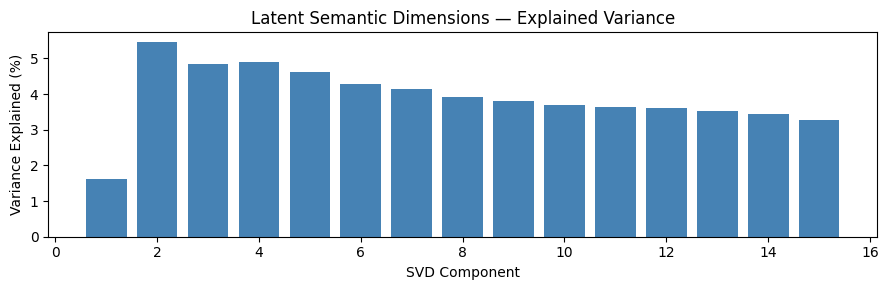

In [ ]:
N_COMPONENTS = 15

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=10, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)
lsa_matrix_norm = normalize(lsa_matrix, norm='l2')

explained_var = svd.explained_variance_ratio_.sum() * 100
print(f'TruncatedSVD fitted:')
print(f'  V^T components shape : {svd.components_.shape}  (learned parameters)')
print(f'  LSA embedding shape  : {lsa_matrix_norm.shape}')
print(f'  Variance explained   : {explained_var:.1f}%')

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(1, N_COMPONENTS + 1), svd.explained_variance_ratio_ * 100, color='steelblue')
ax.set(xlabel='SVD Component', ylabel='Variance Explained (%)', title='Latent Semantic Dimensions — Explained Variance')
plt.tight_layout()
plt.show()

## Cell 6 — ML Step 2: KMeans Clustering

KMeans learns **cluster centroids** from the LSA embeddings — grouping shirts by latent style profile. The fitted `cluster_centers_` are model parameters used during inference to assign new queries to the nearest cluster.

In [ ]:
N_CLUSTERS = 6  # formal / smart-casual / casual-plaid / streetwear / resort / athleisure

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(lsa_matrix_norm)

df_clean = df_clean.copy()
df_clean['cluster'] = cluster_labels

print(f'KMeans fitted:')
print(f'  Centroids shape : {kmeans.cluster_centers_.shape}  (learned parameters)')
print(f'  Inertia         : {kmeans.inertia_:.4f}')
print()
for c in range(N_CLUSTERS):
    members = df_clean[df_clean['cluster'] == c]['name'].tolist()
    print(f'  Cluster {c}: {members}')

KMeans fitted:
  Centroids shape : (6, 15)  (learned parameters)
  Inertia         : 16.1307

  Cluster 0: ['Navy Blue Pinstripe', 'Blue Henley Long Sleeve', 'Teal Mint Henley Long Sleeve', 'Beige Ribbed Knit Long Sleeve', 'Cream Pocket Long Sleeve', 'Denim Chambray Work Shirt']
  Cluster 1: ['Classic White Oxford', 'Grey Herringbone Oxford', 'Pastel Pink Oxford', 'Pale Yellow Oxford Buttondown', 'Dark Green Slim Poplin']
  Cluster 2: ['Brick Red Madras Plaid', 'Grey Melange Patch Long Sleeve', 'Navy Linen Pocket Long Sleeve', 'Burgundy Outdoor Long Sleeve', 'Royal Blue Batik Print', 'Slate Grey Performance Shirt']
  Cluster 3: ['Charcoal Flannel Check', 'Red Tartan Flannel', 'Brown Buffalo Check', 'Forest Green Flannel Plaid']
  Cluster 4: ['White Minimal Long Sleeve', 'Beige Oversized Long Sleeve', 'Black Designer Long Sleeve', 'Black Branded Long Sleeve', 'White Graphic Trail Long Sleeve', 'Grey Essentials Long Sleeve']
  Cluster 5: ['Teal Poplin Dress Shirt', 'Slim Black Formal Dre

## Cell 7 — Elbow Curve (K Selection Validation)

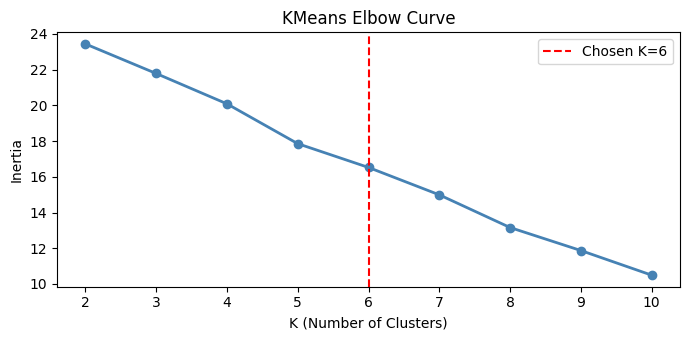

In [ ]:
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(lsa_matrix_norm).inertia_ for k in range(2, 11)]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(2, 11), inertias, 'o-', color='steelblue', linewidth=2)
ax.axvline(x=N_CLUSTERS, color='red', linestyle='--', label=f'Chosen K={N_CLUSTERS}')
ax.set(xlabel='K (Number of Clusters)', ylabel='Inertia', title='KMeans Elbow Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 8 — Recommendation Engine (Hybrid LSA + Cluster Scoring)

In [ ]:
CLUSTER_BONUS = 0.15

def find_outfits(query: str, top_k: int = 3) -> pd.DataFrame:
    """
    Recommend full-sleeve shirts using the trained ML pipeline:
      1. Vectorize query with fitted TfidfVectorizer
      2. Project into learned LSA latent space (fitted TruncatedSVD V^T)
      3. Cosine similarity in latent space (handles synonyms)
      4. Assign query to nearest KMeans cluster (fitted centroids)
      5. Cluster bonus: shirts in same cluster get +0.15
      6. Re-rank by hybrid score
    """
    query_tfidf = vectorizer.transform([query.lower()])
    query_lsa   = svd.transform(query_tfidf)
    query_lsa_n = normalize(query_lsa, norm='l2')

    lsa_scores    = cosine_similarity(query_lsa_n, lsa_matrix_norm).flatten()
    query_cluster = kmeans.predict(query_lsa_n)[0]
    bonus         = np.where(df_clean['cluster'].values == query_cluster, CLUSTER_BONUS, 0.0)
    final_scores  = lsa_scores + bonus

    top_idx = final_scores.argsort()[::-1][:top_k]
    rows = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_clean.iloc[idx]
        rows.append({
            'rank': rank, 'name': row['name'], 'style': row['style'],
            'color': row['color'], 'pattern': row['pattern'],
            'lsa_score': round(float(lsa_scores[idx]), 4),
            'cluster_bonus': round(float(bonus[idx]), 4),
            'final_score': round(float(final_scores[idx]), 4),
            'cluster': int(row['cluster']),
            'image_url': row['image_url'],
            'description': row['description'],
        })
    return pd.DataFrame(rows)


def display_results(results: pd.DataFrame):
    if results.empty:
        print('No results.')
        return
    print(f'Top {len(results)} Recommendations  |  Query cluster: {results.iloc[0]["cluster"]}\n' + '─' * 65)
    for _, r in results.iterrows():
        bonus = f' (+{r["cluster_bonus"]} cluster bonus)' if r['cluster_bonus'] > 0 else ''
        print(f"\n#{int(r['rank'])}  {r['name']}")
        print(f"    Style   : {r['style']}  |  Color: {r['color']}  |  Pattern: {r['pattern']}")
        print(f"    Score   : {r['lsa_score']}{bonus}  →  Final: {r['final_score']}")
        print(f"    Image   : {r['image_url']}")
        print(f"    Details : {r['description'][:120]}...")
    print('\n' + '─' * 65)

print('Recommendation engine ready.')

Recommendation engine ready.


## Cell 9 — Demo Queries

In [ ]:
# Semantic test: 'cozy warm' not in dataset — SVD bridges to flannel/plaid shirts
q = 'cozy warm shirt for cold winter weather'
print(f'Query: "{q}"')
display_results(find_outfits(q))

Query: "cozy warm shirt for cold winter weather"
Top 3 Recommendations  |  Query cluster: 3
─────────────────────────────────────────────────────────────────

#1  Red Tartan Flannel
    Style   : casual  |  Color: red black  |  Pattern: tartan plaid
    Score   : 0.9391 (+0.15 cluster bonus)  →  Final: 1.0891
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/man-plaid-shirt/1.webp
    Details : Bold red and black tartan flannel shirt for colder months. Warm, eye-catching plaid ideal for Christmas holidays, cozy w...

#2  Brown Buffalo Check
    Style   : casual  |  Color: brown black  |  Pattern: buffalo check
    Score   : 0.4312 (+0.15 cluster bonus)  →  Final: 0.5812
    Image   : https://images.pexels.com/photos/769733/pexels-photo-769733.jpeg?auto=compress&cs=tinysrgb&w=400
    Details : Earthy brown and black buffalo check flannel. Timeless pattern with warm cotton flannel. Pairs with jeans or chinos for ...

#3  Forest Green Flannel Plaid
    Style   : casual  |

In [ ]:
q = 'formal blue shirt for office meeting'
print(f'Query: "{q}"')
display_results(find_outfits(q))

Query: "formal blue shirt for office meeting"
Top 3 Recommendations  |  Query cluster: 0
─────────────────────────────────────────────────────────────────

#1  Navy Blue Pinstripe
    Style   : formal  |  Color: navy blue  |  Pattern: striped
    Score   : 0.7714  →  Final: 0.7714
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/blue-&-black-check-shirt/2.webp
    Details : Navy blue shirt with fine white pinstripes. Professional for business meetings and corporate environments. Wool blend fo...

#2  Grey Herringbone Oxford
    Style   : formal  |  Color: grey  |  Pattern: herringbone
    Score   : 0.6172 (+0.15 cluster bonus)  →  Final: 0.7672
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/blue-&-black-check-shirt/3.webp
    Details : Subtle grey herringbone weave oxford. Textured pattern adds visual depth. Reliable business-casual choice for colder mon...

#3  Classic White Oxford
    Style   : formal  |  Color: white  |  Pattern: plain
    Score

In [ ]:
q = 'bright colorful beach vacation holiday shirt'
print(f'Query: "{q}"')
display_results(find_outfits(q))

Query: "bright colorful beach vacation holiday shirt"
Top 3 Recommendations  |  Query cluster: 2
─────────────────────────────────────────────────────────────────

#1  Brick Red Madras Plaid
    Style   : casual  |  Color: brick red  |  Pattern: madras plaid
    Score   : 0.6499 (+0.15 cluster bonus)  →  Final: 0.7999
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/man-plaid-shirt/3.webp
    Details : Bright brick red madras plaid in lightweight cotton. Wear open over a tee or buttoned at barbecues, garden parties, and ...

#2  Royal Blue Batik Print
    Style   : resort casual  |  Color: royal blue  |  Pattern: batik printed
    Score   : 0.5716 (+0.15 cluster bonus)  →  Final: 0.7216
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/blue-&-black-check-shirt/2.webp
    Details : Royal blue cotton voile with artisan batik wax-resist print. Lightweight and culturally rich for cultural festivals, tra...

#3  Navy Linen Pocket Long Sleeve
    Style   : 

In [ ]:
q = 'streetwear graphic printed shirt for night out party'
print(f'Query: "{q}"')
display_results(find_outfits(q))

Query: "streetwear graphic printed shirt for night out party"
Top 3 Recommendations  |  Query cluster: 4
─────────────────────────────────────────────────────────────────

#1  Black Branded Long Sleeve
    Style   : streetwear  |  Color: black  |  Pattern: plain
    Score   : 0.8918 (+0.15 cluster bonus)  →  Final: 1.0418
    Image   : https://files.catbox.moe/p0mmts.jpg
    Details : Versatile black branded long-sleeve in heavy cotton jersey. Bold graphic text across the chest. A streetwear staple for ...

#2  Black Designer Long Sleeve
    Style   : streetwear  |  Color: black  |  Pattern: plain
    Score   : 0.8475 (+0.15 cluster bonus)  →  Final: 0.9975
    Image   : https://files.catbox.moe/pjyh2a.jpg
    Details : Premium black long-sleeve jersey from designer streetwear. Clean minimal branding on quality cotton. Effortlessly elevat...

#3  Grey Essentials Long Sleeve
    Style   : streetwear  |  Color: grey  |  Pattern: printed graphic
    Score   : 0.6705 (+0.15 cluster bonus) 

In [ ]:
q = 'athletic performance gym workout sport shirt'
print(f'Query: "{q}"')
display_results(find_outfits(q))

Query: "athletic performance gym workout sport shirt"
Top 3 Recommendations  |  Query cluster: 2
─────────────────────────────────────────────────────────────────

#1  Slate Grey Performance Shirt
    Style   : athleisure  |  Color: slate grey  |  Pattern: plain
    Score   : 0.9801 (+0.15 cluster bonus)  →  Final: 1.1301
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/blue-&-black-check-shirt/3.webp
    Details : Slate grey performance shirt with moisture-wicking polyester-spandex. Four-way stretch for full range of motion at the g...

#2  Burgundy Outdoor Long Sleeve
    Style   : resort casual  |  Color: burgundy dark red  |  Pattern: plain
    Score   : 0.7008 (+0.15 cluster bonus)  →  Final: 0.8508
    Image   : https://files.catbox.moe/reawti.jpg
    Details : Rich burgundy performance long-sleeve in moisture-wicking polyester blend. Worn with a relaxed fit — ideal for outdoor a...

#3  Grey Melange Patch Long Sleeve
    Style   : casual  |  Color: grey melange

## Cell 10 — Save ML Model Bundle with Pickle

In [ ]:
MODEL_PATH = 'outfit_finder_model.pkl'

model_bundle = {
    'vectorizer':      vectorizer,      # fitted TfidfVectorizer (vocabulary, idf weights)
    'svd':             svd,             # fitted TruncatedSVD (V^T components — learned params)
    'kmeans':          kmeans,          # fitted KMeans (cluster_centers_ — learned params)
    'lsa_matrix_norm': lsa_matrix_norm, # L2-normalised LSA embeddings for all 30 shirts
    'df':              df_clean,        # shirt catalog with cluster assignments
    'n_components':    N_COMPONENTS,
    'n_clusters':      N_CLUSTERS,
    'cluster_bonus':   CLUSTER_BONUS,
    'version':         '3.0.0',
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Model saved → {MODEL_PATH}  ({size_kb:.1f} KB)')
print(f'Contains: TfidfVectorizer + TruncatedSVD (V^T) + KMeans (centroids) + dataset')

Model saved → outfit_finder_model.pkl  (199.1 KB)
Contains: TfidfVectorizer + TruncatedSVD (V^T) + KMeans (centroids) + dataset


## Cell 11 — Load from Pickle & Round-Trip Verification

In [ ]:
with open(MODEL_PATH, 'rb') as f:
    m = pickle.load(f)

_vec, _svd, _km, _lsa, _df, _cb = (
    m['vectorizer'], m['svd'], m['kmeans'], m['lsa_matrix_norm'], m['df'], m['cluster_bonus']
)

def infer(query: str, top_k: int = 3) -> pd.DataFrame:
    q_tfidf = _vec.transform([query.lower()])
    q_lsa   = normalize(_svd.transform(q_tfidf), norm='l2')
    scores  = cosine_similarity(q_lsa, _lsa).flatten()
    bonus   = np.where(_df['cluster'].values == _km.predict(q_lsa)[0], _cb, 0.0)
    final   = scores + bonus
    top_idx = final.argsort()[::-1][:top_k]
    return pd.DataFrame([{'rank': r+1, 'name': _df.iloc[i]['name'], 'score': round(float(final[i]),4)}
                         for r, i in enumerate(top_idx)])

test_q = 'formal office shirt'
orig   = find_outfits(test_q)['name'].tolist()
loaded = infer(test_q)['name'].tolist()

print(f'Pickle round-trip : [{"PASS" if orig == loaded else "FAIL"}]')
print(f'Model version     : {m["version"]}')
print(f'SVD V^T shape     : {_svd.components_.shape}')
print(f'KMeans centroids  : {_km.cluster_centers_.shape}')
print(f'Vocabulary size   : {len(_vec.vocabulary_)}')
infer(test_q)

Pickle round-trip : [PASS]
Model version     : 3.0.0
SVD V^T shape     : (15, 1286)
KMeans centroids  : (6, 15)
Vocabulary size   : 1286


,rank,name,score
0,1,Teal Poplin Dress Shirt,0.8853
1,2,Slim Black Formal Dress Shirt,0.8444
2,3,Classic White Oxford,0.7762


## Cell 12 — Interactive Search (Change Query & Run)

In [ ]:
# ── Edit query here ───────────────────────────────────────────────────────────
YOUR_QUERY = 'red plaid flannel shirt for christmas winter'
TOP_K      = 3
# ─────────────────────────────────────────────────────────────────────────────

results = find_outfits(YOUR_QUERY, top_k=TOP_K)
display_results(results)

try:
    from IPython.display import display, HTML
    cards = ''
    for _, r in results.iterrows():
        bonus_tag = "<span style='color:#27ae60;font-size:11px'> +cluster bonus</span>" if r['cluster_bonus'] > 0 else ''
        cards += f"""
        <div style="display:inline-block;margin:12px;width:220px;vertical-align:top;
                    font-family:sans-serif;border-radius:10px;
                    box-shadow:0 2px 12px rgba(0,0,0,.12);overflow:hidden;background:#fff">
            <img src="{r['image_url']}" width="220" height="220"
                 style="object-fit:cover;display:block;"
                 onerror="this.style.background='#eee';this.alt='No Image'" />
            <div style="padding:10px">
                <p style="font-weight:700;margin:0 0 4px;font-size:14px;">#{int(r['rank'])} {r['name']}</p>
                <p style="font-size:12px;color:#555;margin:2px 0;">{r['style'].title()} · {r['color']}</p>
                <p style="font-size:11px;color:#888;margin:2px 0;">Pattern: {r['pattern']}</p>
                <p style="font-size:12px;margin:4px 0;">Score: <b>{r['final_score']}</b>{bonus_tag}</p>
            </div>
        </div>"""
    display(HTML(f'<div style="background:#f5f5f5;padding:16px;border-radius:12px">{cards}</div>'))
except ImportError:
    pass

Top 3 Recommendations  |  Query cluster: 3
─────────────────────────────────────────────────────────────────

#1  Red Tartan Flannel
    Style   : casual  |  Color: red black  |  Pattern: tartan plaid
    Score   : 0.9557 (+0.15 cluster bonus)  →  Final: 1.1057
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/man-plaid-shirt/1.webp
    Details : Bold red and black tartan flannel shirt for colder months. Warm, eye-catching plaid ideal for Christmas holidays, cozy w...

#2  Forest Green Flannel Plaid
    Style   : casual  |  Color: forest green  |  Pattern: plaid
    Score   : 0.6123 (+0.15 cluster bonus)  →  Final: 0.7623
    Image   : https://cdn.dummyjson.com/product-images/mens-shirts/man-plaid-shirt/2.webp
    Details : Rugged forest green plaid flannel for the outdoors. Warm and durable for camping, hiking, and autumn activities. Classic...

#3  Brown Buffalo Check
    Style   : casual  |  Color: brown black  |  Pattern: buffalo check
    Score   : 0.4675 (+0.15 c

## Cell 13 — Dataset & Model Summary

In [ ]:
print('=== ML Pipeline ===')
print(f'  TfidfVectorizer  : {len(vectorizer.vocabulary_)} terms, bigrams, sublinear_tf')
print(f'  TruncatedSVD     : {N_COMPONENTS} latent dims, {explained_var:.1f}% variance explained')
print(f'  KMeans           : {N_CLUSTERS} clusters, inertia={kmeans.inertia_:.4f}')
print(f'  Hybrid scoring   : LSA cosine + {CLUSTER_BONUS} cluster bonus')
print(f'  Model size       : {os.path.getsize(MODEL_PATH)/1024:.1f} KB')
print()
print('=== Dataset ===')
print(f'  Total shirts: {len(df_clean)}')
for col in ['style','pattern','fabric','fit']:
    print(f'\n  {col.capitalize()}:')
    print(df_clean[col].value_counts().to_string(header=False))

print('\n=== Image Sources ===')
dj = sum(1 for u in df_clean['image_url'] if 'dummyjson' in u)
px = sum(1 for u in df_clean['image_url'] if 'pexels' in u)
kg = sum(1 for u in df_clean['image_url'] if 'catbox.moe' in u)
print(f'  DummyJSON product renders : {dj} shirts (full-sleeve 3D product shots on white bg)')
print(f'  Pexels on-person photos   : {px} shirts (confirmed full-sleeve, worn by model)')
print(f'  catbox.moe CDN            : {kg} shirts (permanent, anonymous CDN)')
print(f'  All URLs verified during image validation (Cell 3)')


=== ML Pipeline ===
  TfidfVectorizer  : 1286 terms, bigrams, sublinear_tf
  TruncatedSVD     : 15 latent dims, 58.7% variance explained
  KMeans           : 6 clusters, inertia=16.1307
  Hybrid scoring   : LSA cosine + 0.15 cluster bonus
  Model size       : 199.1 KB

=== Dataset ===
  Total shirts: 30

  Style:
casual           9
smart casual     8
formal           6
streetwear       3
resort casual    3
athleisure       1

  Pattern:
plain              17
plain henley        2
printed graphic     2
striped             1
herringbone         1
ribbed textured     1
tartan plaid        1
checked             1
buffalo check       1
plaid               1
madras plaid        1
batik printed       1

  Fabric:
cotton                     6
cotton jersey              4
flannel                    3
cotton fleece              2
wool blend                 1
poplin cotton              1
velvet                     1
ribbed cotton              1
oxford cotton              1
poplin                 